In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats


In [45]:
import illustris_python as il

In [46]:
from astropy import units as u

In [47]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

/tmp/ipykernel_28693/82325636.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
def plot_histogram(df, props, labels=None, bins=100, log=True, legend_labels=None, xlim=None):
    scale = 0.7
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    legendsize = 50*scale

    if len(props) > 1:
        alpha = 0.5
    else:
        alpha = 1

    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    for i, prop in enumerate(props):
        if log:
            input_val = np.log10(df[prop])
        else:
            input_val = df[prop]
        if legend_labels == None:
            ax.hist(input_val, bins=100, density=True, alpha=alpha, range=xlim)
        else:
            ax.hist(input_val, bins=100, density=True, alpha=alpha, label = legend_labels[i], range=xlim)
    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)
    if legend_labels != None:
        plt.legend(fontsize=legendsize)
    plt.show()
    return

In [50]:
def plot_fesc_dependence(df, prop, labels=None, log=False, modes=None, plt_labels=None):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    scattersize = 30*scale
    legendsize = 50*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')

    if modes == None:
        modes= ['r', '2r', 'sf_r', 'sf_2r']
        plt_labels = modes
    
    if log:
        input_val = np.log10(df[prop])
    else:
        input_val = df[prop]

    for mode, label in zip(modes, plt_labels):
        ax.scatter(input_val, df['f_esc_'+mode], s=scattersize, label=label, alpha=0.5)

    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)
    plt.legend(fontsize=legendsize)
    plt.ylim(0, 1.05)
    plt.show()
    return

In [51]:
def plot_prop_dependence(df, prop_x, prop_y, labels=None, log_x=False, log_y=False, xlim=None, ylim=None):
    scale = 0.5
    labelsize = 55*scale
    x_tick_major_size = 16*scale
    x_tick_major_width = 4*scale
    x_tick_minor_size = 8*scale
    x_tick_minor_width = 3*scale
    fig_width = 25*scale
    fig_height = 15*scale
    axes_width = 3*scale
    tick_labelsize = 35*scale
    scattersize = 30*scale
    legendsize = 50*scale
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
        
    ax = plt.axes()
    ax.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    
    if log_x:
        x_val = np.log10(df[prop_x])
    else:
        x_val = df[prop_x]

    if log_y:
        y_val = np.log10(df[prop_y])
    else:
        y_val = df[prop_y]

    ax.scatter(x_val, y_val, s=scattersize)
    
    if labels != None:
        ax.set_xlabel(labels['x'], size=labelsize)
        ax.set_ylabel(labels['y'], size=labelsize)

    if xlim != None:
        plt.xlim(xlim[0], xlim[1])
    if ylim != None:
        plt.ylim(ylim[0], ylim[1])
    plt.show()
    return

In [52]:
def describe_to_latex(desc_obj):
    print(r'\begin{tabular}{|c|c|}')
    for name, element in zip(desc_obj.index, desc_obj):
        print(r'\hline')
        name = name.replace(r'%', r'\%')
        print(name, '&', '{:.2f}'.format(element), r'\\')
    print(r'\hline')
    print(r'\end{tabular}')
    return

In [53]:
def get_scatter(df, halo_prop='M_star_sun', bins=30, threshold=1e-2, y_axis='f_esc', lum_weighted=False):
    
    x_values = df.loc[:,halo_prop]
    edges = np.logspace(np.log10(x_values.min()),np.log10(x_values.max()), bins)
    
    means = []
    quantile16 = []
    quantile84 = []
    error = []
    centers = []
    variance = []
    frac_small_arr = []
    
    skip_next = 0
    for i in range(len(edges)-1):
        if skip_next > 0:
            skip_next -= 1
            continue
        sub_fesc = df[(edges[i]*(1-1e-10)<df[halo_prop]) & (df[halo_prop]<edges[i+1])][y_axis]
        center = np.exp((np.log(edges[i+1])+np.log(edges[i]))/2.)
        
        add_bins = 1
        while len(sub_fesc)<10:
            if (i+add_bins) >= (len(edges)):
                break
            sub_fesc = df[(edges[i]*(1-1e-10)<df[halo_prop]) & (df[halo_prop]<edges[i+add_bins])][y_axis]
            center = np.exp((np.log(edges[i+add_bins])+np.log(edges[i]))/2.)
            add_bins += 1
            skip_next += 1

        means.append(sub_fesc.mean())
        centers.append(center)
        quantile16.append(sub_fesc.quantile(0.16))
        quantile84.append(sub_fesc.quantile(0.84))
        error.append(sub_fesc.std()/np.sqrt(sub_fesc.shape[0]))
        variance.append(sub_fesc.var())
        frac_small_arr.append((sub_fesc < threshold).sum()/len(sub_fesc))
        
    means = np.array(means)
    quantile16 = np.array(quantile16)
    quantile84= np.array(quantile84)
    error = np.array(error) 
    centers = np.array(centers)
    variance = np.array(variance)
    frac_small_arr = np.array(frac_small_arr)
    return centers, means, quantile16, quantile84, error, variance, frac_small_arr

In [54]:
def plot_scatter(df, halo_prop='M_star_sun', bins=30, threshold=1e-2, include_frac=False, lum_weighted=False, include_var=False, lin=False):
    
    linewidth = 4
    upper_y_threshold = 1.
    lower_y_threshold_lin = 0.
    size_label = 50
    x_tick_major_size = 16
    x_tick_major_width = 4
    x_tick_minor_size = 8
    x_tick_minor_width = 3
    legend_fontsize = 35
    legend_loc = 'upper right'
    fig_width = 15
    fig_height = 15
    axes_width = 3
    tick_labelsize = 35
    y_lim_low = 0
    y_lim_high = 1.05

    scatter_size = 10
    alpha = 0.5
    
    
    var_lim_low = 1e-3
    var_lim_high = 0.3

    if halo_prop == 'M_star_sun':    
        x_label = '$M_{\star} [\log(M_{\u2609})]$'
        plot_col = 1
        prop = halo_prop
    else:
        raise ValueError("Only defined for the properties 'M_star_sun'")
        
    y_axis_sfr = 'f_esc_r' 
    y_axis_bpass = 'f_esc_sf_r'
    median_label_sfr = r'$\langle f_\mathrm{esc}(\mathrm{SFR}) \rangle $'
    median_label_bpass = r'$\langle f_\mathrm{esc}(\mathrm{BPASS}) \rangle $'
    y_label = '$f_\mathrm{esc}$'
    var_label = '$\mathrm{var}(f_\mathrm{esc})$'
    low_esc_label = '$P(f_\mathrm{esc}<10^{-2})$'

    centers_sfr, means_sfr, _, _, error_sfr, variance_sfr, frac_small_arr_sfr = get_scatter(df, halo_prop=prop, 
                                                                    bins=bins,
                                                                    y_axis=y_axis_sfr,
                                                                    threshold=threshold)

    centers_bpass, means_bpass, _, _, error_bpass, variance_bpass, frac_small_arr_bpass = get_scatter(df, halo_prop=prop, 
                                                                    bins=bins,
                                                                    y_axis=y_axis_bpass,
                                                                    threshold=threshold)
    
    f = plt.figure()
    plt.subplots_adjust(hspace=0.001)
    plt.subplots_adjust(wspace=0.001)

    if include_var and include_frac:
        ax1 = plt.subplot2grid((4, 1), (0,0), rowspan=2)
    elif include_var or include_frac:
        ax1 = plt.subplot2grid((3, 1), (0,0), rowspan=2)
    else:
        ax1 = plt.subplot2grid((2, 1), (0,0), rowspan=2)
    
    x_bins_sfr = np.log10(centers_sfr)
    ax1.plot(x_bins_sfr, means_sfr, linewidth=linewidth,  color='black', label=median_label_sfr)
    ax1.scatter(np.log10(df['M_star_sun']), df['f_esc_sf_r'], s=scatter_size, alpha=alpha)
    x_bins_bpass = np.log10(centers_bpass)
    ax1.plot(x_bins_bpass, means_bpass, linewidth=linewidth,  color='black', linestyle='--', label=median_label_bpass)
    ax1.scatter(np.log10(df['M_star_sun']), df['f_esc_r'], s=scatter_size, alpha=alpha)
    if lin:
        ax1.set_ylim(lower_y_threshold_lin, upper_y_threshold)
    else:
        ax1.set_yscale('log')
        #ax1.set_ylim(threshold, upper_y_threshold)
    ax1.set_ylabel(y_label, size=size_label)
    ax1.tick_params(length=x_tick_major_size, width=x_tick_major_width)
    ax1.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    ax1.legend(fontsize=legend_fontsize, loc=legend_loc, ncol=2)
    ax1.set_rasterization_zorder(-15)
    ax1.set_xlim(6)
    ax1.axes.xaxis.set_visible(False)
    
    if include_var:
        if include_frac:
            ax2 = plt.subplot2grid((4,1), (2,0), sharex=ax1)
        else:
            ax2 = plt.subplot2grid((3,1), (2,0), sharex=ax1)
        ax2.plot(np.log10(centers_sfr), variance_sfr, linewidth=linewidth, color='black')
        ax2.plot(np.log10(centers_bpass), variance_bpass, linewidth=linewidth, color='black', linestyle='--')
        ax2.set_ylabel(var_label, size=size_label)
        ax2.set_xlabel(x_label, size=size_label)
        ax2.set_yscale('log')
        ax2.set_ylim(var_lim_low,var_lim_high)
        ax2.tick_params(length=x_tick_major_size, width=x_tick_major_width)
        ax2.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
    
    if include_frac:
        if include_var:
            ax3 = plt.subplot2grid((4,plot_col), (3,0), sharex=ax2)
        else:
            ax3 = plt.subplot2grid((3,plot_col), (2,0), sharex=ax1)
        ax3.plot(np.log10(centers_sfr), frac_small_arr_sfr, linewidth=linewidth, color='black')
        ax3.plot(np.log10(centers_bpass), frac_small_arr_bpass, linewidth=linewidth, color='black', linestyle='--')
        ax3.legend(fontsize=legend_fontsize, loc=legend_loc)
        ax3.set_ylabel(low_esc_label, size=size_label)
        ax3.set_xlabel(x_label, size=size_label)
        ax3.tick_params(length=x_tick_major_size, width=x_tick_major_width)
        ax3.tick_params(length=x_tick_minor_size, width=x_tick_minor_width, which='minor')
        ax3.set_ylim(y_lim_low, y_lim_high)
        
    
    
    plt.rcParams["figure.figsize"] = (fig_width, fig_height)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=tick_labelsize) 
    plt.rc('ytick', labelsize=tick_labelsize) 
    plt.show()
    return

In [55]:
def get_hist_scatter(df, prop, y_axis='f_esc_r', bin_width=0.1, mode='median'):
    
    f_esc = df.loc[:,y_axis]
    x_values = df.loc[:,'M_star_sun']
    x_prop = 'M_star_sun'
           
    x_values_log = np.log10(x_values)
    log_edges = np.arange(x_values_log.min(), x_values_log.max(), bin_width)
    edges = np.power(10, log_edges)
    prop_norm = {}
    prop_norm[prop]=np.zeros(df[x_prop].size, dtype='float32')
    start_index = 0
    end_index = 0
    for i in range(len(edges)-1):
        column = df[(edges[i]*(1-1e-10)<df[x_prop]) & (df[x_prop]<edges[i+1])][prop]
        end_index += len(column)
        if mode == 'median':
            norm_val=column.median()
        elif mode == 'mean':
            norm_val=column.mean()
        
        new_data=column/norm_val

        prop_norm[prop][start_index:end_index] = new_data
        start_index=end_index
    prop_norm[prop] = np.array(prop_norm[prop])
    return x_values, f_esc, prop_norm

In [56]:
def filter_function(array):
    if len(array)>0:
        return np.median(array)
    else:
        return np.nan

In [57]:
def get_levels(hist_cont, thresholds):
    levels = []
    counts = np.sort(hist_cont.flatten())[::-1]
    value_thresholds = counts.sum()*np.array(thresholds)
    for threshold in value_thresholds:
        count_sum = 0
        i = 0
        while count_sum < threshold:
            count_sum += counts[i]
            i += 1
        levels.append(counts[i])
    #print(levels)
    return levels

In [67]:
def plot_hist_color(df, prop, y_axis='f_esc_r', bin_width=0.1, mode='median', label=None, 
                    small_scale=False, bins=[50,50], levels=[10,30]):
        
    x_labelsize = 50
    y_labelsize = 50

    length_major_ticks = 16
    length_minor_ticks = 8
    width_minor_ticks = 3
    width_major_ticks = 4
    labelsize_x_ticks = 35
    labelsize_y_ticks = 35
    
    colorbar_labelsize = 50
    colorbar_ticklabelsize = 35
    
    axes_width = 3
    
    figure_width = 20
    figure_height = 20
    x_prop = 'M_star_sun'
    
    if small_scale:
        v_min = 0.8
        v_max = 1.2
    else:
        v_min=0.5
        v_max=2.0

        v_center=1.0
    
    x_label = '$M_{\star} [\log(M_{\u2609})]$'
    
    df.sort_values(by='M_star_sun', inplace=True)
    x_values, f_esc, prop_norm = get_hist_scatter(df, prop=prop, bin_width=bin_width, mode=mode)
    
    y_label = '$f_\mathrm{esc}$'
    
    f, ax = plt.subplots()
    
    color_data = prop_norm[prop]
    if label == None:
        bar_label = f'$\Delta ${prop}'
    else: 
        bar_label = label

    col_norm = colors.TwoSlopeNorm(vmin=v_min, vcenter=v_center, vmax=v_max)
    
    hist, xedges, yedges, binnumber = stats.binned_statistic_2d(np.log10(x_values), f_esc, values = color_data, statistic=filter_function, 
                                                                    bins = [bins[0], bins[1]], range=[[6,8],[0,1]])
    hist_cont, xedges_cont, yedges_cont, binnumber_cont = stats.binned_statistic_2d(np.log10(x_values), f_esc, values = color_data, statistic='count', 
                                                                                    bins = [bins[0], bins[1]], range=[[6,8],[0,1]])
    levels = get_levels(hist_cont, thresholds=[0.954, 0.683])
    x_grid, y_grid = np.meshgrid(xedges, yedges)
    cont_centers_x = (xedges_cont[1:]+xedges_cont[:-1])/2
    cont_centers_y = (yedges_cont[1:]+yedges_cont[:-1])/2

    x_grid_cont, y_grid_cont = np.meshgrid(cont_centers_x, cont_centers_y)
    subfig = ax.pcolormesh(x_grid, y_grid, hist.T,norm=col_norm, cmap=plt.get_cmap('coolwarm'))
    levels = levels
    ax.contour(cont_centers_x, cont_centers_y, hist_cont.T, levels=levels, linewidths=5, linestyles=['solid', 'dashed'] , colors='black')

    ax.set_xlabel(x_label, size=x_labelsize)
    ax.set_ylabel(y_label, size=y_labelsize)
    
    # Save the scatter as a rasterization graphic to make the plots smaller
    ax.set_rasterization_zorder(-15)

    ax.tick_params(length=length_major_ticks, width=width_major_ticks)
    ax.tick_params(length=length_minor_ticks, width=width_minor_ticks, which='minor')

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = f.colorbar(subfig, cax=cax)
    cbar.set_label(bar_label, size=colorbar_labelsize)    # Save the scatter as a rasterization graphic to make the plots smaller
    ax.set_rasterization_zorder(-15)
    cbar.ax.tick_params(labelsize=colorbar_ticklabelsize)

    xticklabels = ax.get_xticklabels()
    plt.setp(xticklabels, visible=True)
    plt.rc('axes', linewidth=axes_width)
    plt.rc('xtick', labelsize=labelsize_x_ticks) 
    plt.rc('ytick', labelsize=labelsize_y_ticks) 
    
    plt.rcParams["figure.figsize"] = (figure_width,figure_height)
    plt.tight_layout(rect=(0,0,1,0.7))
    
    plt.show()
    return

In [61]:
full_path = f'/ptmp/mpa/ivkos/semianalytic_fesc/sn013/full_df.pickle'
df = pd.read_pickle(full_path)

In [62]:
g_to_msun = (1*u.g).to(u.Msun).value
df['M_star_sun'] = df['M_star_r']*g_to_msun

In [66]:
import matplotlib
matplotlib.__version__

'3.5.2'

AttributeError: module 'matplotlib.colors' has no attribute 'DivergingNorm'

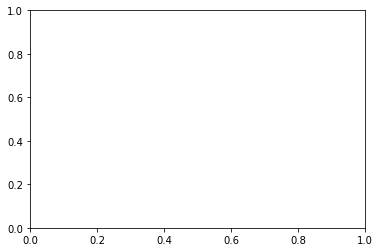

In [63]:
plot_hist_color(df, prop='Dust_norm_r', y_axis='f_esc_r', bin_width=0.1, mode='median', label=None, 
                    small_scale=False, bins=[50,50], levels=[10,30])

In [24]:
plot_scatter(df, halo_prop='M_star_sun', bins=30, threshold=1e-2, include_frac=True, lum_weighted=False, include_var=False, lin=True)

KeyError: 'M_star_sun'

In [61]:
g_to_msun = (1*u.g).to(u.Msun).value
df['M_star_sun'] = np.log10(df['M_star_r']*g_to_msun)

In [45]:
df['r_ratio'] = df['r_sf_r']/df['r']

In [47]:
a = df['r_ratio'].describe()

In [37]:
df['Dust_norm_r'].median()

0.09653282

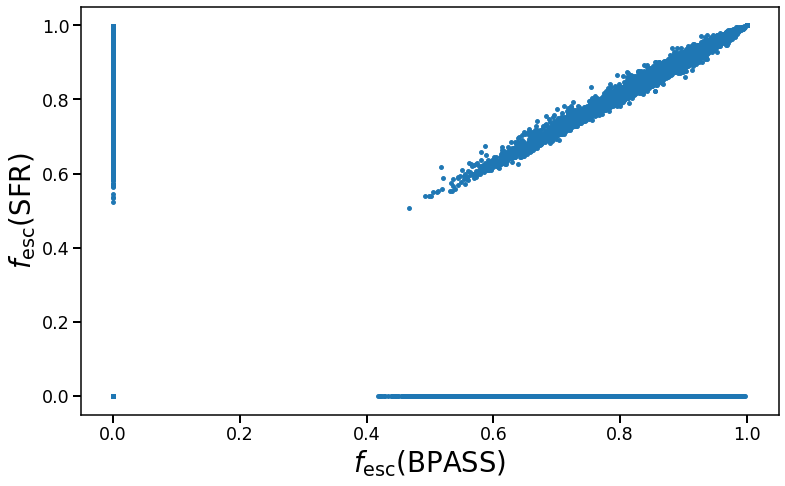

In [24]:
labels = {}
labels['x'] = '$f_\mathrm{esc}$(BPASS)'
labels['y'] = '$f_\mathrm{esc}$(SFR)'
plot_prop_dependence(df, 'f_esc_sf_r', 'f_esc_r', labels=labels, log_x=False, log_y=False)

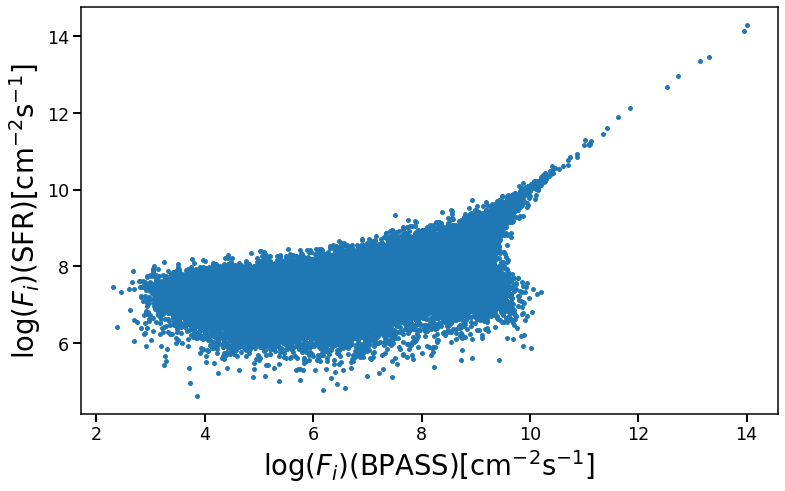

In [28]:
labels = {}
labels['x'] = '$\log(F_i)(\mathrm{BPASS})[\mathrm{cm}^{-2}\mathrm{s}^{-1}]$'
labels['y'] = '$\log(F_i)(\mathrm{SFR})[\mathrm{cm}^{-2}\mathrm{s}^{-1}]$'
plot_prop_dependence(df, "Ion_flux_sf_r", "Ion_flux_r", labels=labels, log_x=True, log_y=True)

In [ ]:
plt.scatter(df['f_g_r'], np.log10(df['Sigma_SFR_r']/conv**2), s=10, c=df['f_esc_r'])
plt.xlabel('$f_{gas,r}$', size=50)
plt.ylabel('$\log (\Sigma_\mathrm{SFR})[M_\odot\mathrm{kpc}^{-2}\mathrm{yr}^{-1}]$', size=50)
cbar = plt.colorbar()
cbar.set_label('$f_\mathrm{esc}$', size=50)

In [206]:
g_to_msun = (1*u.g).to(u.Msun).value
df['M_gas_sun'] = df['M_gas_r']*g_to_msun
df['M_star_sun'] = df['M_star_r']*g_to_msun

In [213]:
cm_to_kpc = (1 * u.cm).to(u.kpc).value
area = df['r']**2*np.pi
df['ionizing_em'] = df["Tot_Ion_em_r"]/area

In [222]:
(df['Tot_Ion_em_r']*df['f_esc_sf_r']).sum()/df['Tot_Ion_em_r'].sum()

0.11066221503753845

In [32]:
(df.f_esc_r*df['Tot_Ion_em_r']).sum()/df['Tot_Ion_em_r'].sum()

0.1211237994535507

In [31]:
(df.f_esc_sf_r*df['Tot_Ion_em_r']).sum()/df['Tot_Ion_em_r'].sum()

0.10311295628258844

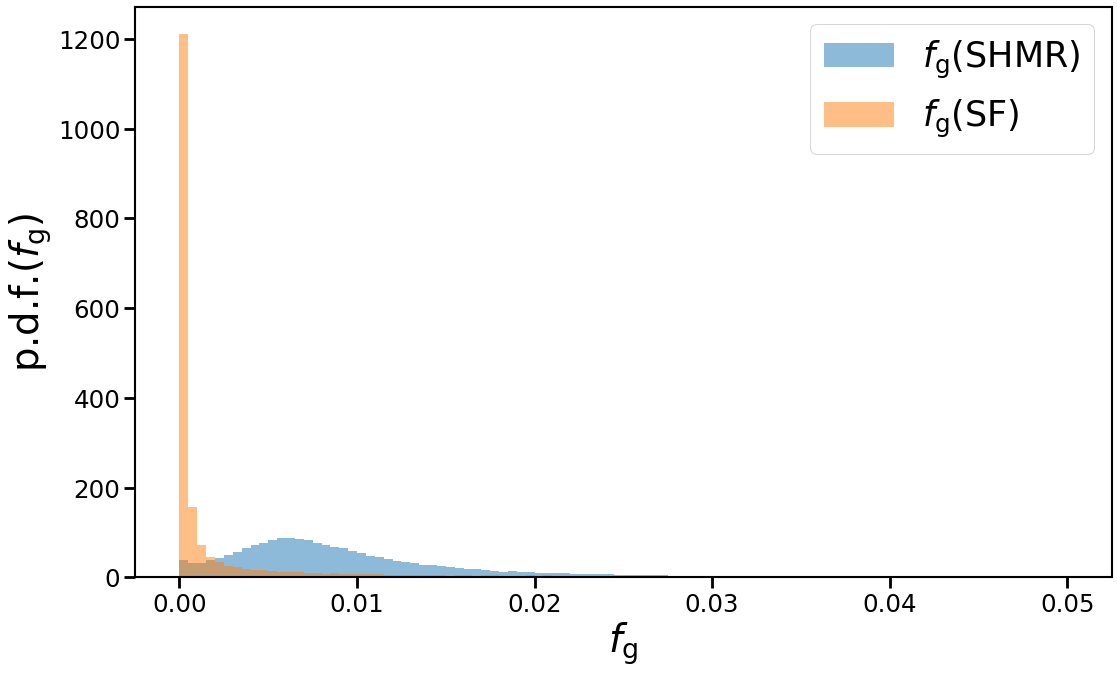

In [22]:
labels = {}
labels['x'] = r'$f_\mathrm{g}$'
labels['y'] = 'p.d.f.($f_\mathrm{g}$)'
props = ['U_r', 'U_sf_r']
legend_labels = ['$f_\mathrm{g}$(SHMR)', '$f_\mathrm{g}$(SF)']
filt = (df.Dust_norm_r>0)&(df.Dust_norm_sf_r>0)
plot_histogram(df, props=props, labels=labels, bins=100, log=False, legend_labels=legend_labels, xlim=(0,0.05))

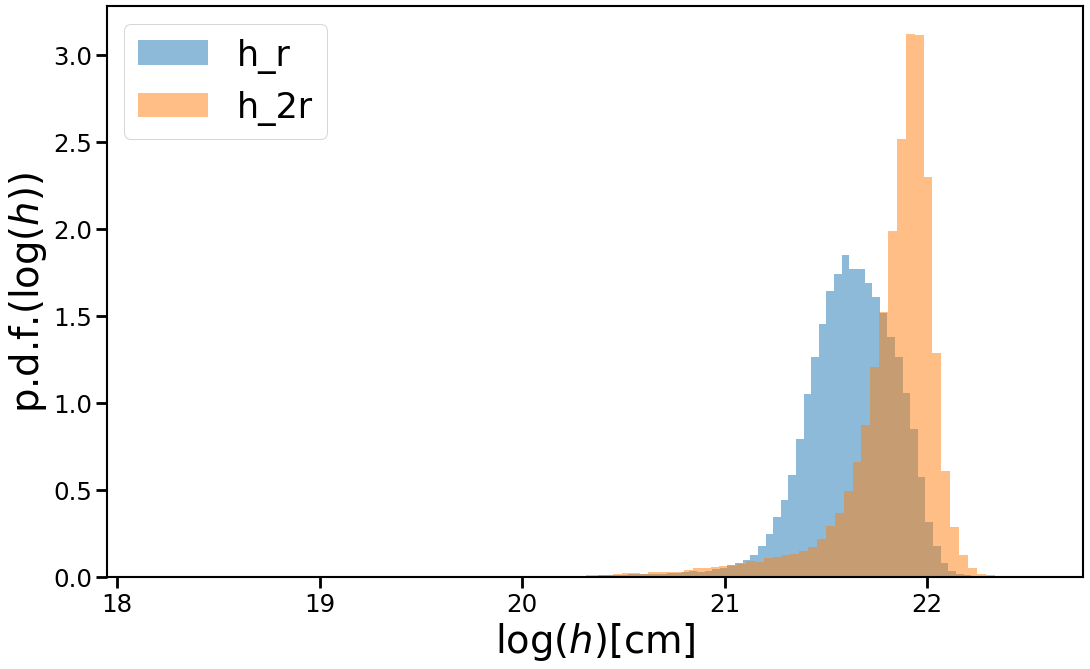

In [23]:
labels = {}
labels['x'] = r'$\log(h)$[cm]'
labels['y'] = 'p.d.f.($\log(h)$)'
props = ['Column_height_r', 'Column_height_2r']
legend_labels = ['h_r', 'h_2r']
plot_histogram(df[df['Column_height_r']>0], props=props, labels=labels, bins=100, log=True, legend_labels=legend_labels)